# House Price Prediction with Linear Regression

Using the **Ames Housing** dataset to predict sale price based on above-grade living area (`Gr Liv Area`).

## Step 1: Install Required Libraries

In [1]:
!pip install pandas matplotlib scikit-learn

## Step 2: Load the Dataset

We load the Ames Housing dataset from the remote CSV URL.

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/mingewang/introduction_ai_ml/main/dataset/AmesHousing.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (2930, 82)
Columns: ['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garag

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


We use `Gr Liv Area` (above-grade living area in sq ft) as the feature and `SalePrice` as the target.

In [3]:
data = df[['Gr Liv Area', 'SalePrice']].dropna().copy()
data.columns = ['Size (sqft)', 'Price']
print(data.describe())
data.head()

       Size (sqft)          Price
count  2930.000000    2930.000000
mean   1499.690444  180796.060068
std     505.508887   79886.692357
min     334.000000   12789.000000
25%    1126.000000  129500.000000
50%    1442.000000  160000.000000
75%    1742.750000  213500.000000
max    5642.000000  755000.000000


,Size (sqft),Price
0,1656,215000
1,896,105000
2,1329,172000
3,2110,244000
4,1629,189900


## Step 3: Visualize the Data

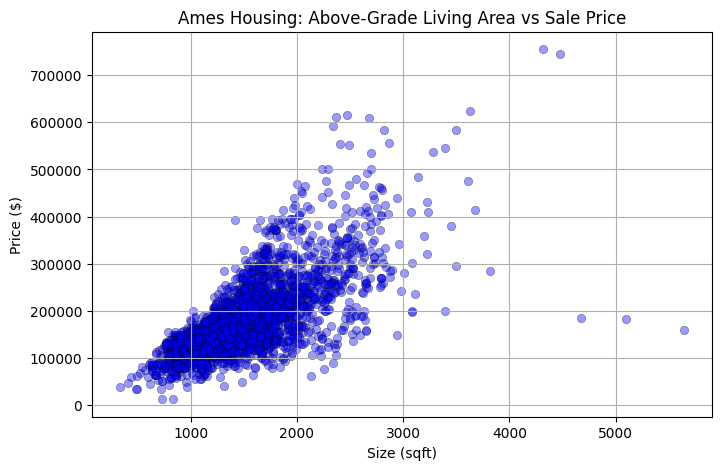

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(data['Size (sqft)'], data['Price'], color='blue', alpha=0.4, edgecolors='k', linewidth=0.5)
plt.title('Ames Housing: Above-Grade Living Area vs Sale Price')
plt.xlabel('Size (sqft)')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

## Step 4: Train the Linear Regression Model

In [5]:
from sklearn.linear_model import LinearRegression

X = data[['Size (sqft)']]
y = data['Price']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m): {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")
print(f"Equation: Price = {slope:.2f} * Size + {intercept:.2f}")

Slope (m): 111.69
Intercept (b): 13289.63
Equation: Price = 111.69 * Size + 13289.63


## Step 5: Make Predictions

In [6]:
predicted_price = model.predict([[1500]])
print(f"Predicted price for 1500 sqft: ${predicted_price[0]:,.2f}")

Predicted price for 1500 sqft: $180,830.64


c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
sizes = [1000, 1500, 2000, 2500, 3000]
predictions = model.predict([[s] for s in sizes])
for sqft, price in zip(sizes, predictions):
    print(f"{sqft:>5} sqft -> ${price:,.2f}")

 1000 sqft -> $124,983.64
 1500 sqft -> $180,830.64
 2000 sqft -> $236,677.64
 2500 sqft -> $292,524.64
 3000 sqft -> $348,371.64


c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Step 6: Plot the Regression Line

c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


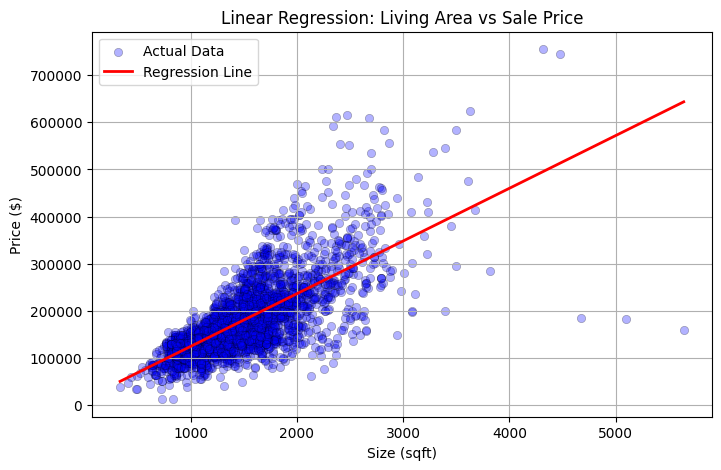

In [8]:
import numpy as np

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.3, edgecolors='k', linewidth=0.5, label='Actual Data')

x_line = np.linspace(X.min().iloc[0], X.max().iloc[0], 100)
y_line = model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression: Living Area vs Sale Price')
plt.xlabel('Size (sqft)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

## Step 7: Evaluation Metrics

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): $3,192,801,087.39
Root Mean Squared Error (RMSE): $56,504.88
R² Score: 0.4995


## Challenge Exercise 1: Predict price for 2000 sqft and 3000 sqft

In [10]:
for size in [2000, 3000]:
    pred = model.predict([[size]])[0]
    print(f"Predicted price for {size} sqft: ${pred:,.2f}")

Predicted price for 2000 sqft: $236,677.64
Predicted price for 3000 sqft: $348,371.64


c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Challenge Exercise 2: Multiple Linear Regression

Add `Total Bsmt SF` (total basement area) as a second feature.

In [11]:
from sklearn.linear_model import LinearRegression

multi = df[['Gr Liv Area', 'Total Bsmt SF', 'SalePrice']].dropna().copy()
multi.columns = ['Size (sqft)', 'Basement (sqft)', 'Price']

X_multi = multi[['Size (sqft)', 'Basement (sqft)']]
y_multi = multi['Price']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print(f"Coefficients: {model_multi.coef_}")
print(f"Intercept: {model_multi.intercept_:,.2f}")

y_pred_multi = model_multi.predict(X_multi)
r2_multi = r2_score(y_multi, y_pred_multi)
print(f"R² Score: {r2_multi:.4f}")

pred = model_multi.predict([[2000, 1000]])[0]
print(f"Predicted price for 2000 sqft + 1000 sqft basement: ${pred:,.2f}")

Coefficients: [83.80721213 71.87222693]
Intercept: -20,453.21
R² Score: 0.6254
Predicted price for 2000 sqft + 1000 sqft basement: $219,033.44


c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Challenge Exercise 3: Polynomial Regression

Use `PolynomialFeatures` to capture non-linear relationships.

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

X_poly = data[['Size (sqft)']]
y_poly = data['Price']

for degree in [2, 3]:
    pipe = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    pipe.fit(X_poly, y_poly)
    y_pred_poly = pipe.predict(X_poly)
    r2_poly = r2_score(y_poly, y_pred_poly)
    print(f"Degree {degree} Polynomial - R² Score: {r2_poly:.4f}")

    pred = pipe.predict([[2000]])[0]
    print(f"  Predicted price for 2000 sqft: ${pred:,.2f}")

Degree 2 Polynomial - R² Score: 0.5061
  Predicted price for 2000 sqft: $240,569.50
Degree 3 Polynomial - R² Score: 0.5177
  Predicted price for 2000 sqft: $241,313.67


c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\mingewang\comrite\introduction_ai_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Compare the r2_score with previous.

Optional: Decision Tree Regressor (random_state=42)  
Optional: Random Forest Regressor (random_state=42)